# Meet your arrays and devices

Runnable locally on CPU or on a Cloud TPU VM.

- Read the table before using an API
- Derive a reduction and its output shape
- Distinguish dtype from mathematical value
- Inspect placement without assuming an accelerator

Imagine a small table: two observations, with three measurements in each row. If we ask JAX to add the values, should it add across the rows or down the columns? Let’s work out both answers before running any code. You’ll learn to check an array’s shape, number format and device, so a plausible-looking result does not hide a mistake.

## The idea

An array is a collection of values with a shape, a dtype and a device. Shape tells us how to index the values; dtype tells us how they are represented; device tells us where the computation lives. Start by predicting a small reduction before asking JAX to perform it.

## Read one array two ways

Take the two rows $[1,2,3]$ and $[4,5,6]$. Summing across each row gives $[6,15]$: one answer per observation. Summing down the rows gives $[5,7,9]$: one answer per feature. The values are the same; the question determines the axis.

In Python, the row sums use `axis=1`, because the feature axis is reduced. The feature sums use `axis=0`, because the observation axis is reduced. The axis you name is the one you consume, not the one you keep.

Read the heatmap by locating one row and one column before looking at its color. Color helps compare values, but labels establish which observation and feature you are comparing. A device label is a separate property; moving the same values to another device does not change what a row means.

$$
Y_{i,j} = \alpha X_{i,j} + \beta, \qquad X \in \mathbb{R}^{M \times N}
$$

### Pause and reason

If the batch gains a third observation with the same three features, which reduction still returns three values?

<details><summary>Compare your reasoning</summary>

The feature sums still return three values because `axis=0` removes the observation axis. Row sums now return three values too, but for a different reason. This is why unequal axis sizes make debugging easier.

</details>

## Read the table before using an API

Start with the six values $0$ through $5$. Reshape them into two rows: $[0, 1, 2]$ and $[3, 4, 5]$. The first axis selects an observation; the second selects a measurement. Shape $(2, 3)$ describes that organization, not the numerical values. Reshape preserves element count and ordering here; it does not create new measurements.

A length-six array and a two-by-three array contain the same values but invite different operations. In your notebook, write an axis label beside each dimension. This becomes important when a later model expects one prediction per row.

```text
flat [0,1,2,3,4,5] → rows [[0,1,2],[3,4,5]]
axis 0: observations (2)
axis 1: measurements (3)
```

## Derive a reduction and its output shape

Summing along axis $1$ removes the measurement axis and leaves one number per observation. The first row sums to $3$, the second to $12$, so the result has shape $(2,)$. Summing along axis $0$ instead combines observations and leaves three measurement totals: $[3, 5, 7]$.

A reduction can also keep the reduced axis with `keepdims=True.` Column means then have shape $(1, 3)$, which states explicitly that the same three means are subtracted from every row. Derive the numbers and shape before using sum or mean.

```text
(2,3) --sum(axis=1)--> (2,) : [3,12]
(2,3) --sum(axis=0)--> (3,) : [3,5,7]
```

## Distinguish dtype from mathematical value

Dtype describes storage and arithmetic, not whether a value happens to be an integer. The value $3$ can be represented as int32 or float32. This lesson asks for float32 explicitly so later differentiation uses an inexact input. Do not infer precision from the way Python prints a scalar.

Float32 cannot represent every real number, or even every large integer. An exact-looking printed value is not a guarantee of exact arithmetic. Keep dtype in an experiment record and compare with tolerances when arithmetic is approximate.

## Inspect placement without assuming an accelerator

`jax.devices()` lists available devices; `x.devices()` describes the placement of this array. A CPU result is useful evidence of CPU execution. It is separate from that a TPU runtime is installed or that a model scales across devices.

Creating a NumPy copy brings values into host memory for inspection. Converting a scalar with float also requires a concrete value. Those are useful boundaries for tests and reports; repeated transfers inside a training loop can distort performance. Use device metadata to inspect placement and an explicit synchronization point for timing later.

## Prepare the inputs

Create main.py in your lesson workspace. Add this first block; use the environment from setup.

In [1]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp

These explicit inputs define the case that the later checks will verify.

## Build the computation

Append this block below the inputs in the same file.

In [2]:
# Step 2 — Build the computation: x has two observations and three features.
# Construct and reshape `x` into the target tensor dimensions.
x = jnp.arange(6, dtype=jnp.float32).reshape(2, 3)

$x$ has two observations and three features. `axis=0` removes the observation dimension, so the means describe features; the centered result retains both axes.

## Run and check the result

Append the checks, save main.py, and run python main.py from this folder using your course environment.

In [3]:
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Print the observed values to compare against the expected result.
print("Shape:", x.shape)
# Print diagnostic summary of the computed outputs.
print("Dtype:", x.dtype)
# Print diagnostic summary of the computed outputs.
print("Devices:", x.devices())
# Print diagnostic summary of the computed outputs.
print("Row sums:", x.sum(axis=1))
# Check tensor shape invariant: `x.shape == (2, 3)`
assert x.shape == (2, 3)
# Assert that `jnp.allclose(x.sum(axis=1), jnp.array([3., 12.]))`.
assert jnp.allclose(x.sum(axis=1), jnp.array([3., 12.]))

Shape: (2, 3)
Dtype: float32
Devices: {CpuDevice(id=0)}
Row sums: [ 3. 12.]


Compare the output to the expected result below before making the exercise change.

## Run the example

In [4]:
# Step 1 — Prepare the inputs: These explicit inputs define the case that the later checks will...
# Import jax for this computation.
import jax
import jax.numpy as jnp
# Step 2 — Build the computation: x has two observations and three features.
# Construct and reshape `x` into the target tensor dimensions.
x = jnp.arange(6, dtype=jnp.float32).reshape(2, 3)
# Step 3 — Run and check the result: Compare the output to the expected result below before making the...
# Print the observed values to compare against the expected result.
print("Shape:", x.shape)
# Print diagnostic summary of the computed outputs.
print("Dtype:", x.dtype)
# Print diagnostic summary of the computed outputs.
print("Devices:", x.devices())
# Print diagnostic summary of the computed outputs.
print("Row sums:", x.sum(axis=1))
# Check tensor shape invariant: `x.shape == (2, 3)`
assert x.shape == (2, 3)
# Assert that `jnp.allclose(x.sum(axis=1), jnp.array([3., 12.]))`.
assert jnp.allclose(x.sum(axis=1), jnp.array([3., 12.]))

Shape: (2, 3)
Dtype: float32
Devices: {CpuDevice(id=0)}
Row sums: [ 3. 12.]


Expected: Shape: $(2, 3)$; Dtype: float32; Row sums: [ $3$. $12$.]. Device names vary.

## Rows are groups of observations

Predict: Which row should sum to $12$?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Rows are groups of observations
# Compute `visual_data` from `{'kind': 'heatmap', 'values': x.tolist(), 'rows': ['...`
visual_data = {'kind': 'heatmap', 'values': x.tolist(), 'rows': ['row 0', 'row 1'], 'columns': ['feature 0', 'feature 1', 'feature 2'], 'unit': 'array value'}

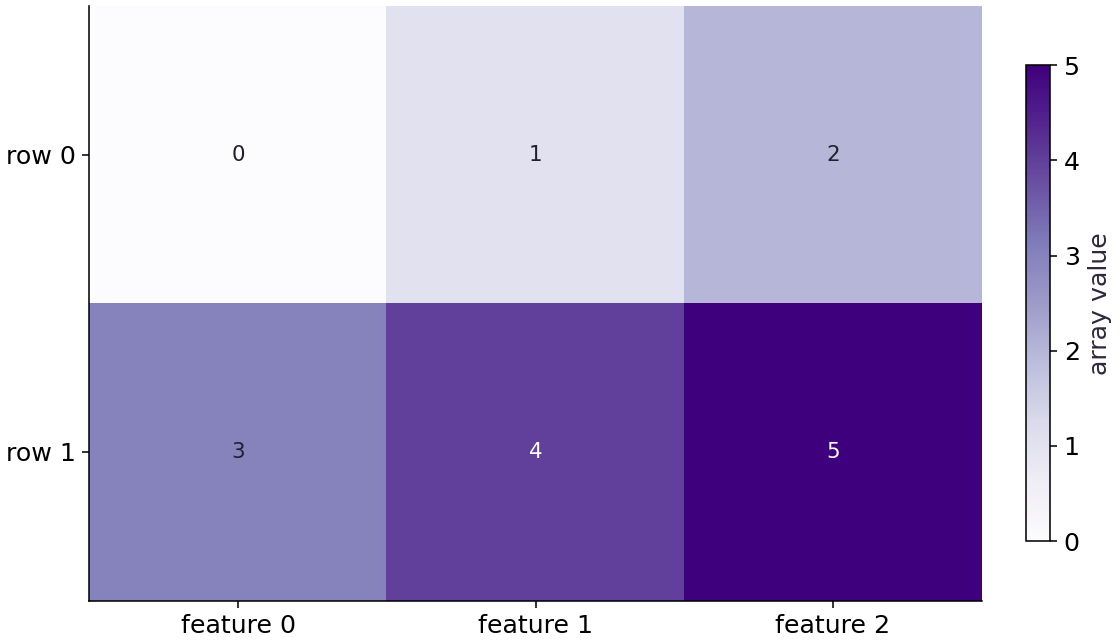

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis selects a feature column; the vertical axis selects an observation row. Each cell contains one array value. The color bar maps larger numbers to darker purple: the bottom-right cell is darkest because it contains $5$.

Read across the top row to find $(0,1,2)$, then across the bottom row to find $(3,4,5)$. The picture therefore represents an array with shape $(2,3)$: two observations, each with three features.

### Connect it to the computation

Now connect the picture to a reduction. Summing the feature columns within each row gives $0+1+2=3$ and $3+4+5=12$. That is why summing along axis $1$ returns two values. Summing down rows instead would return $(3,5,7)$, one value per feature.

The row labels are positions, not times or class labels. The darker lower row tells us its stored values are larger; it does not imply that the observation is more important.

## Center each measurement

Predict: Predict the three column means and every centered value. Which mean is shared by the two observations?

In [7]:
# Experiment — Center each measurement: The calculation reuses one mean per column.
# Reduce along axis=0 to compute `means`.
means=x.mean(axis=0,keepdims=True)
# Compute `centered` from `x-means`
centered=x-means
# Print the observed values to compare against the expected result.
print("Means:",means)
# Print diagnostic summary of the computed outputs.
print("Centered:",centered)
# Check tensor shape invariant: `means.shape==(1,3)`
assert means.shape==(1,3)
# Assert that `jnp.allclose(centered,jnp.array([[-1.5,-1.5,-1.5],[1.5,1.5,1.5]]))`.
assert jnp.allclose(centered,jnp.array([[-1.5,-1.5,-1.5],[1.5,1.5,1.5]]))

Means: [[1.5 2.5 3.5]]
Centered: [[-1.5 -1.5 -1.5]
 [ 1.5  1.5  1.5]]


Expected: Means $[[1.5,2.5,3.5]]$; centered rows are $-1.5$ and $+1.5$.

The calculation reuses one mean per column. An explicit hand calculation verifies both the values and the meaning of the reduction.

## Keep a host reference

Predict: Will copying to NumPy preserve values and shape? Does that copy describe device-resident computation?

In [8]:
# Experiment — Keep a host reference: The host reference is an inspection copy.
# Import numpy for this computation.
import numpy as np
# Convert `host` to a host NumPy array for inspection or verification.
host=np.asarray(x)
# Check tensor shape invariant: `host.shape==(2,3)`
assert host.shape==(2,3)
# Create evenly spaced index values in ``.
np.testing.assert_array_equal(host,np.arange(6).reshape(2,3))
# Print the observed values to compare against the expected result.
print("Host dtype:",host.dtype)

Host dtype: float32


Expected: A NumPy array with the same two-by-three values.

The host reference is an inspection copy. Its existence says nothing about accelerator throughput.

## Your exercise

Compute column sums instead. State the resulting shape before running the code.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Reduce along axis=0 to compute `column_sums`.
2. Check tensor shape invariant: `column_sums.shape == (3,)`
3. Assert that `jnp.allclose(column_sums, jnp.array([3., 5., 7.]))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compute column sums instead.
# Reduce along axis=0 to compute `column_sums`.
column_sums = x.sum(...)  # TODO: compute column_sums
# Check tensor shape invariant: `column_sums.shape == (3,)`
assert column_sums.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(column_sums, jnp.array([3., 5., 7.]))`.
assert jnp.allclose(column_sums, jnp.array([3., 5., 7.]))  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compute column sums instead.
# Reduce along axis=0 to compute `column_sums`.
# column_sums = x.sum(...)  # TODO: compute column_sums
# Check tensor shape invariant: `column_sums.shape == (3,)`
# assert column_sums.shape  # TODO: complete assertion check
# Assert that `jnp.allclose(column_sums, jnp.array([3., 5., 7.]))`.
# assert jnp.allclose(column_sums, jnp.array([3., 5., 7.]))  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Compute column sums instead.
# Reduce along axis=0 to compute `column_sums`.
column_sums = x.sum(axis=0)
# Check tensor shape invariant: `column_sums.shape == (3,)`
assert column_sums.shape == (3,)
# Assert that `jnp.allclose(column_sums, jnp.array([3., 5., 7.]))`.
assert jnp.allclose(column_sums, jnp.array([3., 5., 7.]))

## Add a new observation · Practice

Append $[6,7,8]$. Predict row sums and column means, then check both.

Hint: Keep observation rows and measurement columns.

### How to write: Add a new observation — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.arange(n, dtype=...)` — Creates a 1-D JAX array of evenly spaced values `[0, 1, ..., n-1]` on the target device.
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).

**Step-by-step implementation plan:**
1. Construct and reshape `table` into the target tensor dimensions.
2. Assert that `jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))`.
3. Assert that `jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))`.

**Starter code scaffold (fill in the TODOs):**

```python
# Add a new observation (Practice): Changing the observation count changes axis 0, while the...
# Construct and reshape `table` into the target tensor dimensions.
table = jnp.arange(...)  # TODO: compute table
# Assert that `jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))`.
assert jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))`.
assert jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Add a new observation (Practice): Changing the observation count changes axis 0, while the...
# Construct and reshape `table` into the target tensor dimensions.
# table = jnp.arange(...)  # TODO: compute table
# Assert that `jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))`.
# assert jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))  # TODO: complete assertion check
# Assert that `jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))`.
# assert jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))  # TODO: complete assertion check

## Reference reasoning

Changing the observation count changes axis $0$, while the measurement count stays three.

In [12]:
# Add a new observation (Practice): Changing the observation count changes axis 0, while the...
# Construct and reshape `table` into the target tensor dimensions.
table=jnp.arange(9,dtype=jnp.float32).reshape(3,3)
# Assert that `jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))`.
assert jnp.allclose(table.sum(axis=1),jnp.array([3.,12.,21.]))
# Assert that `jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))`.
assert jnp.allclose(table.mean(axis=0),jnp.array([3.,4.,5.]))

## Diagnose an impossible reshape · Challenge

Try reshaping six values to $(2,4)$. Explain the failure and repair the intended three-measurement table.

Hint: Count required elements before changing the code.

### How to write: Diagnose an impossible reshape — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:
2. Assert invariant `x.reshape(2,3).size==6` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Diagnose an impossible reshape (Challenge): An incompatible reshape is an element-count error.
# Run the boundary check and catch the expected exception:
try:
    x.reshape(2,4)
except TypeError:
    print("Expected element-count mismatch")
else:
    raise AssertionError("Expected reshape to fail")
# Assert invariant `x.reshape(2,3).size==6` holds
assert x.reshape(2,3).size  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Diagnose an impossible reshape (Challenge): An incompatible reshape is an element-count error.
# Run the boundary check and catch the expected exception:
# try:
#     x.reshape(2,4)
# except TypeError:
#     print("Expected element-count mismatch")
# else:
#     raise AssertionError("Expected reshape to fail")
# Assert invariant `x.reshape(2,3).size==6` holds
# assert x.reshape(2,3).size  # TODO: complete assertion check

## Reference reasoning

An incompatible reshape is an element-count error. Changing a dtype or moving devices cannot fix it. Choose a shape whose product matches six.

In [14]:
# Diagnose an impossible reshape (Challenge): An incompatible reshape is an element-count error.
# Run the boundary check and catch the expected exception:
try:
    x.reshape(2,4)
except TypeError:
    print("Expected element-count mismatch")
else:
    raise AssertionError("Expected reshape to fail")
# Assert invariant `x.reshape(2,3).size==6` holds
assert x.reshape(2,3).size==6

Expected element-count mismatch


## Checkpoint

For an array of shape $(2, 3)$, what shape results from `sum(axis=0)`?

1. $(2,)$
2. $(3,)$
3. $(2, 3)$

## Diagnose

An incompatible reshape is an element-count error. Changing a dtype or moving devices cannot fix it. Choose a shape whose product matches six.

## Evidence

Keep the labeled table, row/column calculations, centered-data check, array dtype/device report and the failed reshape with its element-count diagnosis.

## Carry forward

- The calculation reuses one mean per column. An explicit hand calculation verifies both the values and the meaning of the reduction.
- The host reference is an inspection copy. Its existence says nothing about accelerator throughput.

## Primary references

- [JAX arrays](https://docs.jax.dev/en/latest/101/arrays.html)
- [JAX data placement](https://docs.jax.dev/en/latest/201/placement.html)